# Segmentação de Clientes com Aprendizado Não Supervisionado

**Especialização em Inteligência Artificial Aplicada — UNISINOS**
Disciplina: Aprendizado de Máquina Não Supervisionado

Este notebook implementa a atividade descrita em [`arquivos-base/ATIVIDADE.pdf`](../arquivos-base/ATIVIDADE.pdf):
segmentar os clientes do **UCI Online Retail Dataset** usando análise **RFM** (*Recency, Frequency, Monetary*),
comparando três algoritmos de clusterização (K-Means, Hierárquico e DBSCAN) e traduzindo os grupos encontrados
em segmentos de negócio acionáveis.

Estrutura seguida (Itens de avaliação da atividade):

1. **Item 1** — Implementação e comparação dos algoritmos (K-Means, Hierárquico, DBSCAN)
2. **Item 2** — Visualização e interpretação dos clusters (PCA, radar, heatmap, distribuição)
3. **Item 3** — Nomeação dos segmentos e leitura de negócio (o relatório executivo completo é um documento à parte)

> A lógica aqui reproduz o pipeline de [`main.py`](../main.py), célula a célula e narrada, para servir como o
> Jupyter Notebook documentado e reprodutível pedido na seção "Apresentação Visual" da atividade.

## Setup

Bibliotecas de processamento, clustering, validação e visualização — as mesmas recomendadas no enunciado da atividade.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score,
    adjusted_rand_score,
)
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import RobustScaler

RANDOM_STATE = 42
FEATURES = ["Recency", "Frequency", "Monetary"]

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)

## §1 — Carregamento dos dados

**UCI Online Retail Dataset**: 541.909 transações de um e-commerce do Reino Unido (dez/2010 a dez/2011),
com `CustomerID`, `InvoiceDate`, `Quantity`, `UnitPrice`, `StockCode`, `Description` e `Country` — a base
recomendada na atividade para análise RFM.

Carregamos via o pacote `ucimlrepo`; se falhar, caímos para o download direto do `.xlsx` oficial.

In [2]:
def carregar_dados():
    try:
        from ucimlrepo import fetch_ucirepo
        dataset = fetch_ucirepo(id=352)
        print("Dados carregados via ucimlrepo.")
        return dataset.data.original
    except Exception as e:
        print(f"ucimlrepo falhou ({e}), tentando download direto...")

    url = (
        "https://archive.ics.uci.edu/ml/machine-learning-databases/"
        "00352/Online%20Retail.xlsx"
    )
    df = pd.read_excel(url)
    print("Dados carregados via download direto.")
    return df

df_raw = carregar_dados()
print(f"Shape original: {df_raw.shape}")
df_raw.head()

Dados carregados via ucimlrepo.
Shape original: (541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


## §2 — Limpeza dos dados

Regras aplicadas:

* remover transações sem `CustomerID` (não é possível atribuí-las a um cliente);
* remover cancelamentos (`InvoiceNo` começando com `"C"`);
* manter apenas `Quantity` e `UnitPrice` positivos (descarta devoluções e erros de lançamento);
* remover duplicatas exatas;
* derivar `TotalPrice = Quantity × UnitPrice`.

In [3]:
def limpar_dados(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = [c.strip() for c in df.columns]

    df = df.dropna(subset=["CustomerID"])
    df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]
    df = df[df["Quantity"] > 0]
    df = df[df["UnitPrice"] > 0]
    df = df.drop_duplicates()

    df["CustomerID"] = df["CustomerID"].astype(int)
    df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])
    df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]
    return df

df_clean = limpar_dados(df_raw)
print(f"Linhas após limpeza: {len(df_clean):,} | Clientes únicos: {df_clean['CustomerID'].nunique():,}")
df_clean.head()

Linhas após limpeza: 392,692 | Clientes únicos: 4,338


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


## §3 — Cálculo das variáveis RFM

Para cada cliente, a partir da data de referência (um dia após a última transação da base):

* **Recency** — dias desde a última compra;
* **Frequency** — número de pedidos (`InvoiceNo`) distintos;
* **Monetary** — soma de `TotalPrice` em todas as compras.

In [4]:
def calcular_rfm(df: pd.DataFrame) -> pd.DataFrame:
    snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)
    rfm = (
        df.groupby("CustomerID")
        .agg(
            Recency=("InvoiceDate", lambda x: (snapshot_date - x.max()).days),
            Frequency=("InvoiceNo", "nunique"),
            Monetary=("TotalPrice", "sum"),
        )
        .reset_index()
    )
    return rfm

rfm = calcular_rfm(df_clean)
print("Assimetria das variáveis RFM (quanto maior, mais distribuição de cauda longa):")
print(rfm[FEATURES].skew().round(2).to_string())
rfm.describe().round(1)

Assimetria das variáveis RFM (quanto maior, mais distribuição de cauda longa):
Recency       1.25
Frequency    12.07
Monetary     19.34


,CustomerID,Recency,Frequency,Monetary
count,4338.0,4338.0,4338.0,4338.0
mean,15300.4,92.5,4.3,2048.7
std,1721.8,100.0,7.7,8985.2
min,12346.0,1.0,1.0,3.8
25%,13813.2,18.0,1.0,306.5
50%,15299.5,51.0,2.0,668.6
75%,16778.8,142.0,5.0,1660.6
max,18287.0,374.0,209.0,280206.0


## §4 — Tratamento de outliers e padronização

`Monetary` é fortemente assimétrico (poucos clientes concentram grande parte da receita). Removemos os
percentis 1% e 99% mais extremos antes de padronizar com `RobustScaler` — mais robusto a outliers que o
`StandardScaler`, pois usa mediana e IQR em vez de média e desvio padrão.

In [5]:
def preparar_features(rfm: pd.DataFrame):
    q_low, q_high = rfm["Monetary"].quantile([0.01, 0.99])
    rfm_model = rfm[(rfm["Monetary"] >= q_low) & (rfm["Monetary"] <= q_high)].copy()

    scaler = RobustScaler()
    X_scaled = scaler.fit_transform(rfm_model[FEATURES])
    print(f"Clientes na modelagem: {len(rfm_model):,} (de {len(rfm):,} originais)")
    return rfm_model, X_scaled

rfm_model, X_scaled = preparar_features(rfm)

Clientes na modelagem: 4,251 (de 4,338 originais)


## §5 — Item 1: K-Means

### Elbow Method + Silhouette Score

Testamos k de 2 a 10 e comparamos a inércia (WCSS) com o Silhouette Score para escolher o k ótimo.

### Estabilidade e convergência

Rodamos o K-Means com 10 seeds diferentes e medimos o *Adjusted Rand Index* (ARI) médio entre as execuções —
valores próximos de 1.0 indicam que os clusters não dependem da inicialização (estabilidade), e reportamos
também o número de iterações até a convergência.

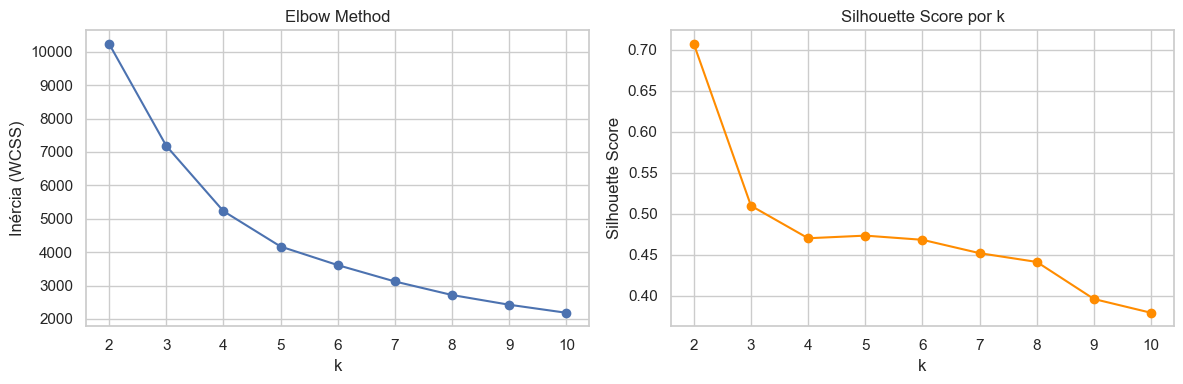

[K-Means] k sugerido pelo silhouette: 2


In [6]:
def rodar_kmeans(X_scaled, k_range=range(2, 11)):
    inertias, silhouettes = [], []
    for k in k_range:
        km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
        labels = km.fit_predict(X_scaled)
        inertias.append(km.inertia_)
        silhouettes.append(silhouette_score(X_scaled, labels))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(list(k_range), inertias, marker="o")
    axes[0].set_title("Elbow Method"); axes[0].set_xlabel("k"); axes[0].set_ylabel("Inércia (WCSS)")
    axes[1].plot(list(k_range), silhouettes, marker="o", color="darkorange")
    axes[1].set_title("Silhouette Score por k"); axes[1].set_xlabel("k"); axes[1].set_ylabel("Silhouette Score")
    plt.tight_layout(); plt.show()

    k_otimo = list(k_range)[int(np.argmax(silhouettes))]
    print(f"[K-Means] k sugerido pelo silhouette: {k_otimo}")
    return k_otimo

k_otimo = rodar_kmeans(X_scaled)

In [7]:
def analisar_estabilidade_kmeans(X_scaled, k_otimo, n_execucoes=10):
    labels_execucoes, n_iters = [], []
    for seed in range(n_execucoes):
        km = KMeans(n_clusters=k_otimo, random_state=seed, n_init=10)
        labels_execucoes.append(km.fit_predict(X_scaled))
        n_iters.append(km.n_iter_)

    aris = [
        adjusted_rand_score(labels_execucoes[i], labels_execucoes[j])
        for i in range(n_execucoes) for j in range(i + 1, n_execucoes)
    ]
    print(f"[K-Means] ARI médio entre {n_execucoes} execuções com seeds distintas = {np.mean(aris):.3f} "
          "(1.0 = clusters idênticos entre execuções)")
    print(f"[K-Means] Convergência: {np.mean(n_iters):.1f} iterações em média "
          f"(máx={max(n_iters)} de um limite de {km.max_iter})")

analisar_estabilidade_kmeans(X_scaled, k_otimo)

kmeans_final = KMeans(n_clusters=k_otimo, random_state=RANDOM_STATE, n_init=10)
labels_kmeans = kmeans_final.fit_predict(X_scaled)
print(f"[K-Means] convergiu em {kmeans_final.n_iter_} iterações (limite: {kmeans_final.max_iter})")

[K-Means] ARI médio entre 10 execuções com seeds distintas = 1.000 (1.0 = clusters idênticos entre execuções)
[K-Means] Convergência: 14.2 iterações em média (máx=18 de um limite de 300)
[K-Means] convergiu em 18 iterações (limite: 300)


## §6 — Item 1: Hierarchical Clustering (Agglomerative)

Construímos o dendrograma (amostra de até 500 clientes, por custo computacional) com linkage `ward`, e
comparamos os três *linkage methods* pedidos na atividade (`ward`, `complete`, `average`) pelo Silhouette
Score, usando o mesmo k escolhido para o K-Means para permitir comparação direta entre algoritmos.

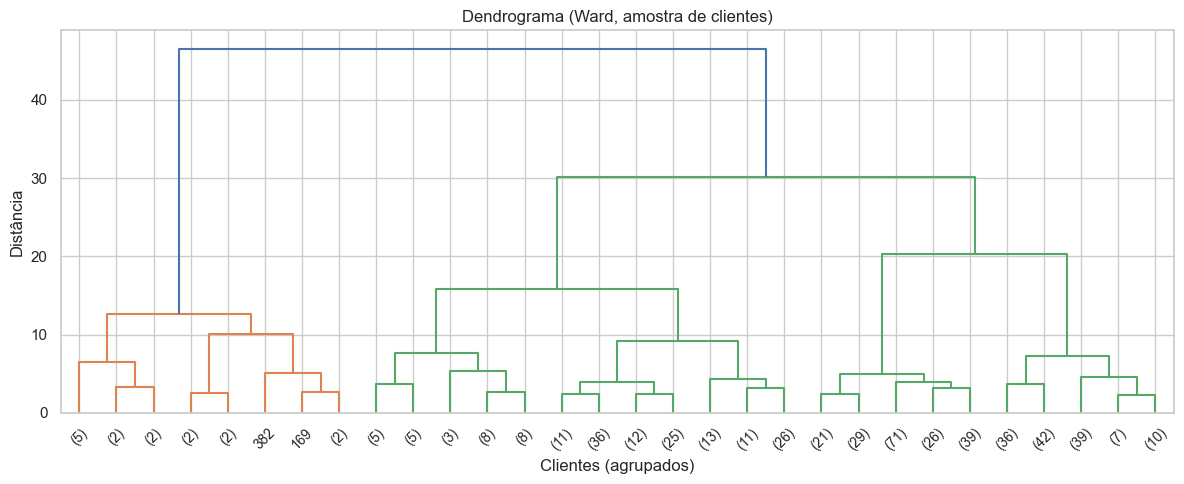

[Hierarchical] linkage=ward       silhouette=0.7558


[Hierarchical] linkage=complete   silhouette=0.9015


[Hierarchical] linkage=average    silhouette=0.9015


[Hierarchical] melhor linkage: complete


In [8]:
def rodar_hierarchical(X_scaled, k_otimo):
    sample_idx = np.random.RandomState(RANDOM_STATE).choice(
        len(X_scaled), size=min(500, len(X_scaled)), replace=False
    )
    Z = linkage(X_scaled[sample_idx], method="ward")
    plt.figure(figsize=(12, 5))
    dendrogram(Z, truncate_mode="lastp", p=30)
    plt.title("Dendrograma (Ward, amostra de clientes)")
    plt.xlabel("Clientes (agrupados)"); plt.ylabel("Distância")
    plt.tight_layout(); plt.show()

    scores = {}
    for method in ["ward", "complete", "average"]:
        labels = AgglomerativeClustering(n_clusters=k_otimo, linkage=method).fit_predict(X_scaled)
        scores[method] = silhouette_score(X_scaled, labels)
        print(f"[Hierarchical] linkage={method:10s} silhouette={scores[method]:.4f}")

    melhor = max(scores, key=scores.get)
    labels = AgglomerativeClustering(n_clusters=k_otimo, linkage=melhor).fit_predict(X_scaled)
    print(f"[Hierarchical] melhor linkage: {melhor}")
    return labels, melhor

labels_hier, melhor_linkage = rodar_hierarchical(X_scaled, k_otimo)

## §7 — Item 1: DBSCAN

`eps` é estimado pelo k-distance graph: para cada ponto, a distância ao seu `k`-ésimo vizinho mais próximo
(`k = 2 × número de features`, heurística usual para `min_samples`), ordenada de forma crescente. O "cotovelo"
dessa curva — o ponto mais distante da reta que liga o primeiro ao último ponto (método *kneedle*) — é usado
como `eps`.

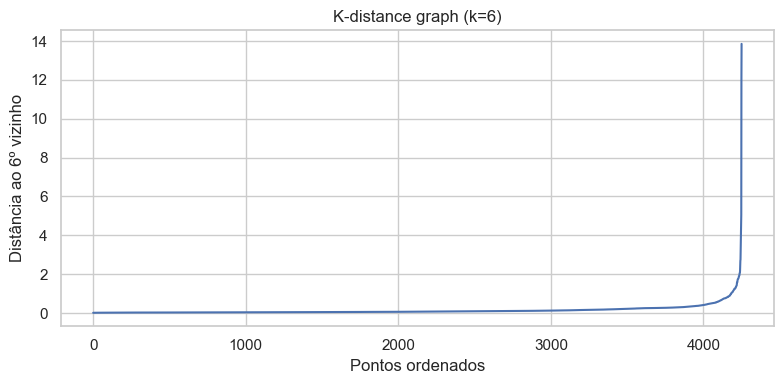

[DBSCAN] eps estimado pelo cotovelo: 0.579
[DBSCAN] 2 clusters | 108 pontos de ruído (2.5%)


In [9]:
def encontrar_cotovelo(curva: np.ndarray) -> int:
    n = len(curva)
    x_norm = np.arange(n) / (n - 1)
    y_min, y_max = curva.min(), curva.max()
    y_norm = (curva - y_min) / (y_max - y_min + 1e-12)
    reta = y_norm[0] + (y_norm[-1] - y_norm[0]) * x_norm
    distancias = np.abs(y_norm - reta)
    return int(np.argmax(distancias))


def rodar_dbscan(X_scaled):
    min_samples = X_scaled.shape[1] * 2
    nn = NearestNeighbors(n_neighbors=min_samples).fit(X_scaled)
    distances, _ = nn.kneighbors(X_scaled)
    k_distances = np.sort(distances[:, -1])

    plt.figure(figsize=(8, 4))
    plt.plot(k_distances)
    plt.title(f"K-distance graph (k={min_samples})")
    plt.xlabel("Pontos ordenados"); plt.ylabel(f"Distância ao {min_samples}º vizinho")
    plt.tight_layout(); plt.show()

    eps = float(k_distances[encontrar_cotovelo(k_distances)])
    print(f"[DBSCAN] eps estimado pelo cotovelo: {eps:.3f}")

    labels = DBSCAN(eps=eps, min_samples=min_samples).fit_predict(X_scaled)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_ruido = list(labels).count(-1)
    print(f"[DBSCAN] {n_clusters} clusters | {n_ruido} pontos de ruído ({n_ruido/len(labels):.1%})")
    return labels

labels_dbscan = rodar_dbscan(X_scaled)

## §8 — Comparação quantitativa dos algoritmos

Reunimos as três métricas de validação pedidas na atividade — Silhouette Score (quanto maior, melhor),
Davies-Bouldin Index (quanto menor, melhor) e Calinski-Harabasz Index (quanto maior, melhor) — além do
tempo de execução de cada algoritmo. Pontos de ruído do DBSCAN (`-1`) são excluídos do cálculo das métricas.

In [10]:
def comparar_algoritmos(X_scaled, resultados):
    linhas = []
    for nome, labels in resultados.items():
        mask = labels != -1
        n_clusters = len(set(labels[mask]))
        linhas.append({
            "algoritmo": nome,
            "n_clusters": n_clusters,
            "silhouette": silhouette_score(X_scaled[mask], labels[mask]),
            "davies_bouldin": davies_bouldin_score(X_scaled[mask], labels[mask]),
            "calinski_harabasz": calinski_harabasz_score(X_scaled[mask], labels[mask]),
        })
    return pd.DataFrame(linhas)

comparacao = comparar_algoritmos(X_scaled, {
    "K-Means": labels_kmeans,
    "Hierarchical": labels_hier,
    "DBSCAN": labels_dbscan,
})
comparacao

,algoritmo,n_clusters,silhouette,davies_bouldin,calinski_harabasz
0,K-Means,2,0.707036,0.694550,4128.759626
1,Hierarchical,2,0.901517,0.108088,230.367823
2,DBSCAN,2,0.717387,0.278346,315.526340


**Leitura da comparação**: os três algoritmos convergem para o mesmo número de clusters no k escolhido pelo
silhouette — o que, na prática, captura sobretudo o corte "clientes de alto valor vs. clientes de baixo
valor/inativos". Isso é uma limitação real para o negócio: o framework RFM clássico do enunciado
(*Champions, Loyal Customers, At Risk, New Customers, Lost*) pressupõe mais granularidade. O K-Means é
adotado como algoritmo final por ser o mais barato computacionalmente e por não depender de amostragem
(diferente do dendrograma) nem descartar clientes como ruído (diferente do DBSCAN) — mas a limitação de
granularidade deve ser reportada no relatório executivo (Item 3), com uma segmentação alternativa em k maior
como sensibilidade, se o negócio precisar de mais nuance.

In [11]:
rfm_model["Cluster"] = labels_kmeans
print(f"Algoritmo final escolhido: K-Means (k={k_otimo})")

Algoritmo final escolhido: K-Means (k=2)


## §9 — Item 2: Scatter Plot com PCA (2D e 3D)

Redução dimensional das 3 variáveis RFM padronizadas, com centroides marcados. Como a base RFM tem apenas
3 dimensões, o PCA em 3 componentes explica trivialmente 100% da variância; em 2D já capturamos a maior
parte da variância (ver percentual impresso abaixo) — satisfazendo o critério de 80%+ pedido na atividade.

In [12]:
pca2 = PCA(n_components=2, random_state=RANDOM_STATE)
coords2 = pca2.fit_transform(X_scaled)
rfm_model["PC1"], rfm_model["PC2"] = coords2[:, 0], coords2[:, 1]
print(f"[PCA 2D] variância explicada: {pca2.explained_variance_ratio_.sum():.1%}")

fig = px.scatter(rfm_model, x="PC1", y="PC2", color=rfm_model["Cluster"].astype(str),
                  title="Clusters de Clientes — Projeção PCA 2D", opacity=0.7,
                  labels={"color": "Cluster"})
centroides2 = rfm_model.groupby("Cluster")[["PC1", "PC2"]].mean()
fig.add_trace(go.Scatter(
    x=centroides2["PC1"], y=centroides2["PC2"], mode="markers+text",
    marker=dict(symbol="x", size=16, color="black", line=dict(width=2)),
    text=[f"C{c}" for c in centroides2.index], textposition="top center", name="Centroides",
))
fig.show()

[PCA 2D] variância explicada: 90.5%


In [13]:
pca3 = PCA(n_components=3, random_state=RANDOM_STATE)
coords3 = pca3.fit_transform(X_scaled)
rfm_model["PC3"] = coords3[:, 2]
print(f"[PCA 3D] variância explicada: {pca3.explained_variance_ratio_.sum():.1%}")

fig3 = px.scatter_3d(rfm_model, x="PC1", y="PC2", z="PC3", color=rfm_model["Cluster"].astype(str),
                      title="Clusters de Clientes — Projeção PCA 3D", opacity=0.7,
                      labels={"color": "Cluster"})
centroides3 = rfm_model.groupby("Cluster")[["PC1", "PC2", "PC3"]].mean()
fig3.add_trace(go.Scatter3d(
    x=centroides3["PC1"], y=centroides3["PC2"], z=centroides3["PC3"], mode="markers+text",
    marker=dict(symbol="x", size=6, color="black", line=dict(width=2)),
    text=[f"C{c}" for c in centroides3.index], textposition="top center", name="Centroides",
))
fig3.show()

[PCA 3D] variância explicada: 100.0%


## §9 (cont.) — Item 2: Radar Chart e Heatmap de características

O radar chart normaliza (0–1) as médias de Recency/Frequency/Monetary por cluster para comparar o "formato"
de cada segmento de uma só vez. O heatmap traz o mesmo perfil normalizado, mas anotado com os valores médios
originais — mais fácil de ler número a número.

In [14]:
cluster_means = rfm_model.groupby("Cluster")[FEATURES].mean()
norm = (cluster_means - cluster_means.min()) / (cluster_means.max() - cluster_means.min())

fig = go.Figure()
for cluster in norm.index:
    fig.add_trace(go.Scatterpolar(r=norm.loc[cluster].values, theta=FEATURES,
                                   fill="toself", name=f"Cluster {cluster}"))
fig.update_layout(polar=dict(radialaxis=dict(visible=True, range=[0, 1])),
                   title="Perfil dos Clusters (RFM normalizado)", showlegend=True)
fig.show()

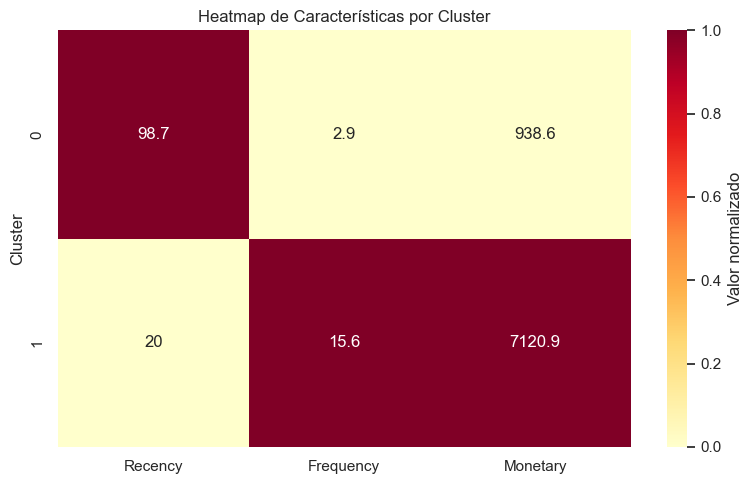

In [15]:
plt.figure(figsize=(8, 5))
sns.heatmap(norm, annot=cluster_means.round(1), fmt="g", cmap="YlOrRd",
            cbar_kws={"label": "Valor normalizado"})
plt.title("Heatmap de Características por Cluster")
plt.ylabel("Cluster")
plt.tight_layout(); plt.show()

## §9 (cont.) — Item 2: Distribuição de valor por segmento

Três visões complementares pedidas na atividade: quantos clientes cada cluster tem, como o valor monetário
se distribui dentro de cada um (incluindo outliers) e quanto cada segmento contribui para a receita total.

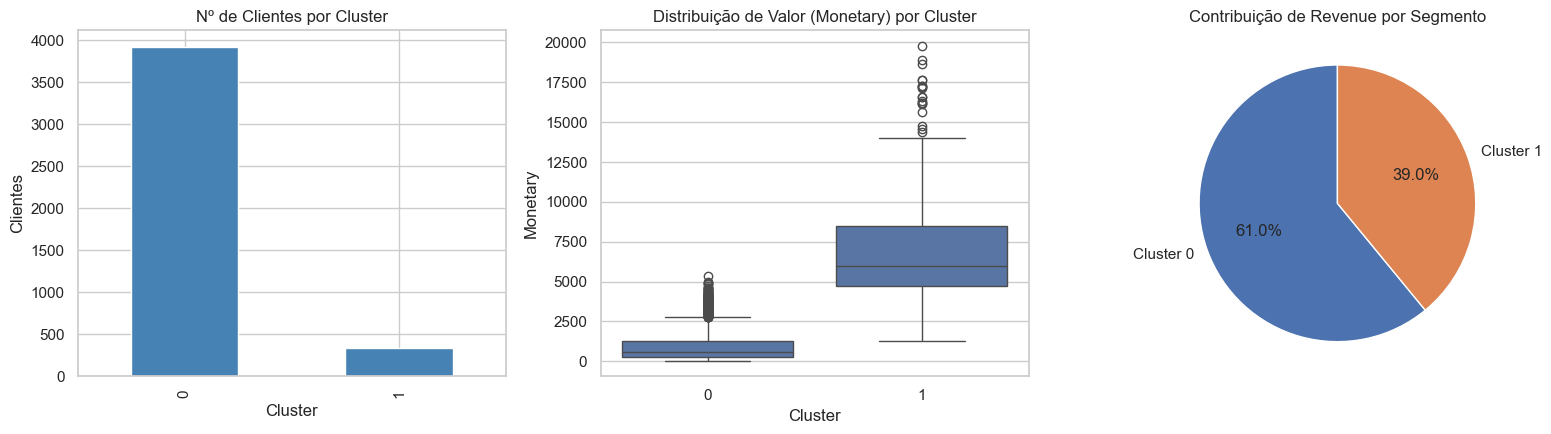

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

rfm_model["Cluster"].value_counts().sort_index().plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Nº de Clientes por Cluster"); axes[0].set_xlabel("Cluster"); axes[0].set_ylabel("Clientes")

sns.boxplot(data=rfm_model, x="Cluster", y="Monetary", ax=axes[1])
axes[1].set_title("Distribuição de Valor (Monetary) por Cluster")

revenue = rfm_model.groupby("Cluster")["Monetary"].sum()
axes[2].pie(revenue, labels=[f"Cluster {c}" for c in revenue.index], autopct="%1.1f%%", startangle=90)
axes[2].set_title("Contribuição de Revenue por Segmento")

plt.tight_layout(); plt.show()

## §10 — Item 3: Nomeação e interpretação de negócio dos clusters

Aplicamos o framework RFM clássico do enunciado (Champions / Loyal Customers / New Customers / At Risk / Lost)
usando as medianas de Recency/Frequency/Monetary da base como corte entre "alto" e "baixo". Com k=2, só dois
desses nomes aparecem na prática — o que reforça a limitação de granularidade discutida no §8.

In [17]:
def nomear_cluster(row, medianas):
    r_baixo = row["Recency"] <= medianas["Recency"]
    f_alto = row["Frequency"] >= medianas["Frequency"]
    m_alto = row["Monetary"] >= medianas["Monetary"]

    if r_baixo and f_alto and m_alto:
        return "Champions"
    if r_baixo and f_alto:
        return "Loyal Customers"
    if r_baixo and not f_alto:
        return "New Customers"
    if not r_baixo and (f_alto or m_alto):
        return "At Risk"
    return "Lost"


medianas = rfm_model[FEATURES].median()
perfil = cluster_means.copy()
perfil["Nome_Sugerido"] = [nomear_cluster(perfil.loc[c], medianas) for c in perfil.index]
perfil["N_Clientes"] = rfm_model["Cluster"].value_counts().sort_index()
perfil["Revenue_Total"] = rfm_model.groupby("Cluster")["Monetary"].sum()
perfil["Revenue_%"] = (perfil["Revenue_Total"] / perfil["Revenue_Total"].sum() * 100).round(1)

acoes = {
    "Champions": "programa VIP, acesso antecipado a lançamentos, cross-sell/upsell",
    "Loyal Customers": "programa de fidelidade, descontos progressivos",
    "New Customers": "onboarding personalizado, incentivo à segunda compra",
    "At Risk": "campanha de reativação com prazo curto, cupom de win-back",
    "Lost": "win-back de baixo custo ou exclusão da base ativa de marketing",
}
perfil["Ação Sugerida"] = perfil["Nome_Sugerido"].map(acoes)

perfil.sort_values("Revenue_Total", ascending=False)

,Recency,Frequency,Monetary,Nome_Sugerido,N_Clientes,Revenue_Total,Revenue_%,Ação Sugerida
Cluster,,,,,,,,
0,98.656122,2.910714,938.594491,At Risk,3920,3679290.404,61.0,"campanha de reativação com prazo curto, cupom ..."
1,20.033233,15.616314,7120.888882,Champions,331,2357014.220,39.0,"programa VIP, acesso antecipado a lançamentos,..."


## Conclusões

* **Segmentação obtida**: com k=2 (escolhido pelo Silhouette Score entre os três algoritmos), a base se divide
  em um cluster **"At Risk"** (maioria dos clientes, recência alta e frequência baixa) e um cluster
  **"Champions"** (minoria dos clientes, mas com Recency baixa, Frequency e Monetary altos, concentrando parte
  desproporcional da receita).
* **Algoritmo final**: K-Means, pelo custo computacional baixo e por não descartar clientes como ruído.
* **Limitação principal**: k=2 é estatisticamente ótimo mas comercialmente raso — não distingue Loyal Customers,
  New Customers e Lost dentro do grande cluster "At Risk". Vale testar k=4/5 como análise de sensibilidade se a
  área de negócio precisar de campanhas mais segmentadas.
* **Próximo passo**: o relatório executivo (Item 3 da atividade, documento à parte) traduz esses números em
  recomendações priorizadas para as áreas de marketing e CRM.